### Data Set : Vehicle/Driver Data

For the sake of simplicity, we will take only two features : mean distance driven per day and the mean percentage of time a driver was >5 mph over the speed limit.

Here are what the data represent:
* id: Unique Id of the driver .
* mean_dist_day: Mean distance driven by driver per day
* mean_over_speed_perc: Mean percentage of time a driver was > 5 mph over the speed limit

#### 1) Importing Necessary Libraries:

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

#### 2) Loading Data:

In [2]:
df = pd.read_csv('driver-data.csv')

In [3]:
df.head()

,id,mean_dist_day,mean_over_speed_perc
0,3423311935,71.24,28
1,3423313212,52.53,25
2,3423313724,64.54,27
3,3423311373,55.69,22
4,3423310999,54.58,25


In [4]:
df.shape

(4000, 3)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    4000 non-null   int64  
 1   mean_dist_day         4000 non-null   float64
 2   mean_over_speed_perc  4000 non-null   int64  
dtypes: float64(1), int64(2)
memory usage: 93.9 KB


In [6]:
df.describe()

,id,mean_dist_day,mean_over_speed_perc
count,4.000000e+03,4000.000000,4000.000000
mean,3.423312e+09,76.041522,10.721000
std,1.154845e+03,53.469563,13.708543
min,3.423310e+09,15.520000,0.000000
25%,3.423311e+09,45.247500,4.000000
50%,3.423312e+09,53.330000,6.000000
75%,3.423313e+09,65.632500,9.000000
max,3.423314e+09,244.790000,100.000000


- "id" is unique for all the records, we can drop it.

In [7]:
df.drop('id', axis= 1, inplace= True)

In [8]:
df.head()

,mean_dist_day,mean_over_speed_perc
0,71.24,28
1,52.53,25
2,64.54,27
3,55.69,22
4,54.58,25


#### 3) Data Exploration and Transformation:

##### 1) mean_dist_day:

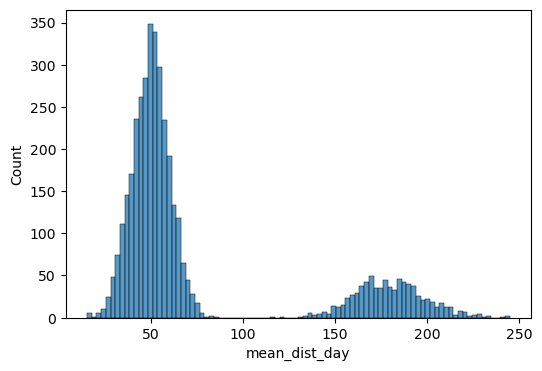

In [9]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'mean_dist_day')
plt.show()

- There are two distinctive distribution in Mean Distance Travelled per Day.
- Most drivers are centered around 50 miles per day and other group is centered around 175 miles per day.

##### 2) mean_over_speed_perc:

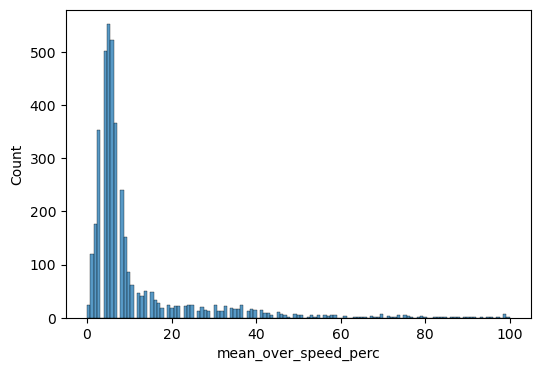

In [10]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'mean_over_speed_perc')
plt.show()

- Distribution is right tailed.
- For most the drivers, percentage of time they were over > 5 mph over speed limit is around 0-20.
- Some drivers are as far as 100% of time over > 5 mph over speed limit.

##### 3) Relations between Features:

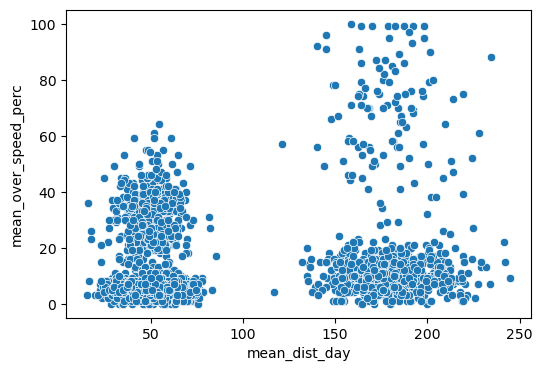

In [11]:
plt.figure(figsize= (6,4))
sns.scatterplot(data= df, x= 'mean_dist_day', y= 'mean_over_speed_perc')
plt.show()

##### 4) Scaling the Features:

In [12]:
sc = StandardScaler()
temp = sc.fit_transform(df)
scaled_df = pd.DataFrame(data= temp, columns= df.columns)
scaled_df.head()

,mean_dist_day,mean_over_speed_perc
0,-0.089810,1.260613
1,-0.439773,1.041744
2,-0.215131,1.187656
3,-0.380666,0.822875
4,-0.401428,1.041744


#### 4) Clustering:

##### 1) 2 Clusters:

In [15]:
kmc2 = KMeans(n_clusters= 2)
clusters_2 = kmc2.fit_predict(scaled_df)

In [16]:
clusters_2

array([0, 0, 0, ..., 1, 1, 1], shape=(4000,), dtype=int32)

In [17]:
# Attaching Clusters Array as another Column to Data Frame:

scaled_df['Clusters_2'] = clusters_2
scaled_df.head()

,mean_dist_day,mean_over_speed_perc,Clusters_2
0,-0.089810,1.260613,0
1,-0.439773,1.041744,0
2,-0.215131,1.187656,0
3,-0.380666,0.822875,0
4,-0.401428,1.041744,0


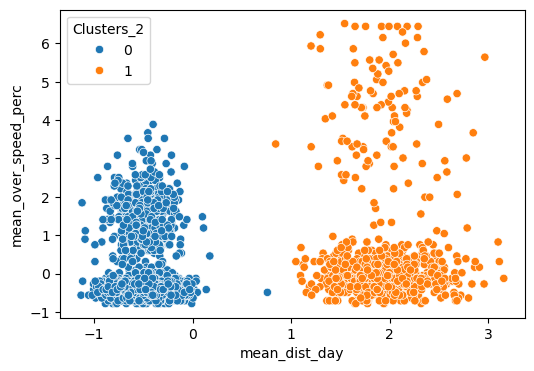

In [18]:
# Visualizing Clusters:

plt.figure(figsize= (6,4))
sns.scatterplot(data= scaled_df, x= 'mean_dist_day', y= 'mean_over_speed_perc', hue= 'Clusters_2')
plt.show()

In [19]:
# Cluster Centers:

kmc2.cluster_centers_

array([[-0.48581565, -0.13816168],
       [ 1.94630276,  0.55351131]])

##### 2) 3 Clusters:

In [30]:
kmc3 = KMeans(n_clusters= 3)
clusters_3 = kmc3.fit_predict(scaled_df.iloc[:, :2]) #Selecting only first two columns
clusters_3

array([1, 0, 1, ..., 2, 2, 2], shape=(4000,), dtype=int32)

In [31]:
scaled_df['Clusters_3'] = clusters_3
scaled_df.head()

,mean_dist_day,mean_over_speed_perc,Clusters_2,Clusters_3
0,-0.089810,1.260613,0,1
1,-0.439773,1.041744,0,0
2,-0.215131,1.187656,0,1
3,-0.380666,0.822875,0,0
4,-0.401428,1.041744,0,0


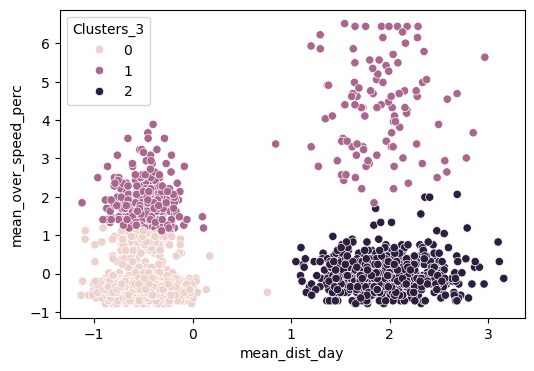

In [32]:
# Visualizing Clusters:

plt.figure(figsize= (6,4))
sns.scatterplot(data= scaled_df, x= 'mean_dist_day', y= 'mean_over_speed_perc', hue= 'Clusters_3')
plt.show()

In [37]:
# Cluster Centers:

kmc3.cluster_centers_

array([[-0.48708051, -0.3464639 ],
       [ 0.14266936,  2.51023743],
       [ 1.95279463, -0.01664897]])

##### 3) 4 Clusters:

In [33]:
kmc4 = KMeans(n_clusters= 4)
clusters_4 = kmc4.fit_predict(scaled_df.iloc[:, :2]) #Selecting only first two columns
scaled_df['Clusters_4'] = clusters_4
scaled_df.head()

,mean_dist_day,mean_over_speed_perc,Clusters_2,Clusters_3,Clusters_4
0,-0.089810,1.260613,0,1,1
1,-0.439773,1.041744,0,0,1
2,-0.215131,1.187656,0,1,1
3,-0.380666,0.822875,0,0,1
4,-0.401428,1.041744,0,0,1


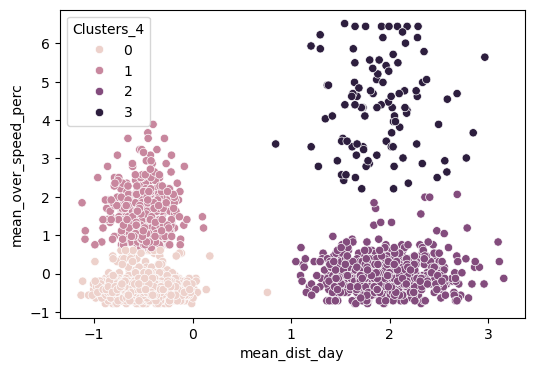

In [36]:
# Visualizing Clusters:

plt.figure(figsize= (6,4))
sns.scatterplot(data= scaled_df, x= 'mean_dist_day', y= 'mean_over_speed_perc', hue= 'Clusters_4')
plt.show()

In [38]:
# Cluster Centers:

kmc4.cluster_centers_

array([[-0.48675314, -0.3981621 ],
       [-0.47952208,  1.60728695],
       [ 1.95263225, -0.0139714 ],
       [ 1.90400473,  4.34582367]])

##### 5) Finding optimal number of Clusters based on Silhouette Score:

- A silhouette score is a metric used in unsupervised learning to evaluate the quality of clustering by measuring how similar each data point is to its own cluster compared to other clusters.
- The score ranges from \(-1\) to \(+1\), where a value near \(+1\) indicates the point is well-clustered and far from other clusters, a value near \(0\) suggests the point is close to the boundary of two clusters, and a negative value indicates the point may be in the wrong cluster.

- How it works:
    - Intra-cluster distance: For each data point, the average distance to all other points in the same cluster is calculated. This is a measure of the point's cohesion within its own cluster.
    - Inter-cluster distance: For each data point, the average distance to all points in the nearest neighboring cluster is calculated.
    - Silhouette coefficient: The silhouette score for a single data point is calculated using the formula:

        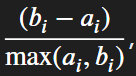

      where \(a_{i}\) is the intra-cluster distance and \(b_{i}\) is the inter-cluster distance.
    - Overall score: The final silhouette score for the entire clustering is the average of all individual data points' silhouette scores.

- Interpretation:
    - \(+1\) (near): The data point is well-clustered and far from other clusters. A high overall score means the clusters are dense and well-separated.
    - \(0\): The data point is on or very close to the decision boundary between two neighboring clusters. This suggests overlapping clusters.
    - \(-1\) (near): The data point is likely assigned to the wrong cluster, as it is closer to another cluster. 

In [41]:
# Looping different number of clusters and calculating silhouette score:

sil_score = []
for num in range(2, 11):
    kmc = KMeans(n_clusters= num)
    clusters = kmc.fit_predict(scaled_df.iloc[:, :2])
    sil_score.append(silhouette_score(X= scaled_df.iloc[:, :2], labels= clusters))

In [43]:
sil_score

[0.6304667352823775,
 0.7637686905937182,
 0.7843727073779272,
 0.7827465218292712,
 0.42503655747246205,
 0.3601762595062937,
 0.3593633991924775,
 0.34261553418707363,
 0.344950916996347]

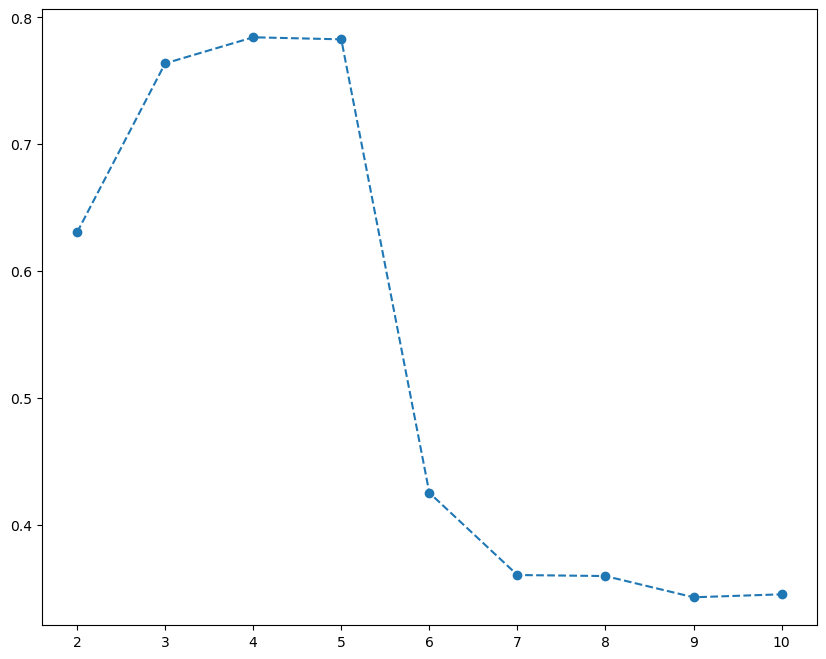

In [50]:
# Visualizing Silhouette Scores to find Optimal Number of Clusters:

plt.figure(figsize= (10,8))
plt.plot(range(2, 11), sil_score, 'o--')
plt.show()

- From graph and silhouette score list, 4 seems to be the Optimal choice for Number of Clusters for this Dataset.